# Transpacific Simulator — Visualisation Notebook

**Data**: 10-year monthly simulation (2015–2024) across 55 routes and 13 markets.

Each section is self-contained — run them in order or jump to any section directly.

| Section | What it shows |
|---|---|
| 1. Setup | Load data, define helpers and colour palette |
| 2. Demand & Load Factor | LF over time, by market, by route, seasonality |
| 3. Yield & Revenue | Economy yield, cabin yield mix, revenue by market |
| 4. Fuel | Fuel price path, cost per flight, fuel % of revenue |
| 5. Payload | Passenger payload by aircraft type and route |
| 6. Shocks | Shock factor timeline, shock depth by market |
| 7. Booking Curves | Beta-distribution curves, reading date snapshots |
| 8. Correlations | Heatmap, LF vs yield scatter, fuel vs revenue |


## 1. Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings("ignore")

# ── Load data ─────────────────────────────────────────────────────────────────
df = pd.read_csv("../output/simulation.csv", parse_dates=["date"])
df["year_month"] = df["date"].dt.to_period("M")

print(f"Loaded {len(df):,} records | {df['flight_od'].nunique()} routes | "
      f"{df['market_country'].nunique()} markets | "
      f"{df['year'].min()}–{df['year'].max()}")
df.head(3)


Loaded 6,600 records | 53 routes | 10 markets | 2015–2024


,year,month,date,flight_od,origin_airport,dest_airport,market_country,market_country_name,is_connecting,connecting_hub,...,dtp01_business_pct,dtp01_premium_eco_booked,dtp01_premium_eco_pct,dtp01_economy_booked,dtp01_economy_pct,fuel_cost_per_ask,rask_usd,rpas_usd,fuel_pct_revenue,year_month
0,2015,1,2015-01-01,HND->LAX,HND,LAX,JP,Japan,0,NaN,...,0.0,0,0.0,0,0.0,0.016159,0.123003,1084.27,0.1314,2015-01
1,2015,1,2015-01-01,HND->JFK,HND,JFK,JP,Japan,0,NaN,...,0.0,0,0.0,0,0.0,0.016159,0.105524,1143.67,0.1531,2015-01
2,2015,1,2015-01-01,HND->ORD,HND,ORD,JP,Japan,0,NaN,...,0.0,0,0.0,0,0.0,0.017137,0.086542,877.80,0.1980,2015-01


In [3]:
# ── Global style & colour palette ─────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi":        130,
    "figure.facecolor":  "white",
    "axes.facecolor":    "#FAFAFA",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.color":        "#E5E5E5",
    "grid.linewidth":    0.6,
    "font.family":       "sans-serif",
    "font.size":         10,
    "axes.titlesize":    12,
    "axes.titleweight":  "bold",
    "legend.frameon":    False,
})

# Market colours
MARKET_COLORS = {
    "JP": "#BA7517",   # amber  — Japan
    "CN": "#E24B4A",   # red    — China
    "KR": "#D4537E",   # rose   — Korea
    "HK": "#534AB7",   # purple — Hong Kong
    "SG": "#1D9E75",   # teal   — Singapore
    "TW": "#378ADD",   # blue   — Taiwan
    "AU": "#2C9B4A",   # green  — Australia
    "US": "#185FA5",   # navy   — United States
    "CA": "#8B4513",   # brown  — Canada
    "GB": "#6B6B6B",   # grey   — UK
    "DE": "#F5A623",   # gold   — Germany
    "NL": "#E8601C",   # orange — Netherlands
    "AE": "#9B2C8C",   # magenta— UAE
}

CABIN_COLORS = {
    "first":       "#185FA5",
    "business":    "#0F6E56",
    "premium_eco": "#BA7517",
    "economy":     "#636363",
}

# Helper: label formatter
def pct_fmt(x, _):  return f"{x:.0%}"
def usd_fmt(x, _):  return f"\${x:,.0f}"
def kusd_fmt(x, _): return f"\${x/1e3:,.0f}K"

print("Setup complete ✓")


Setup complete ✓


---
## 2. Demand & Load Factor

### 2a. Load factor over time — by market

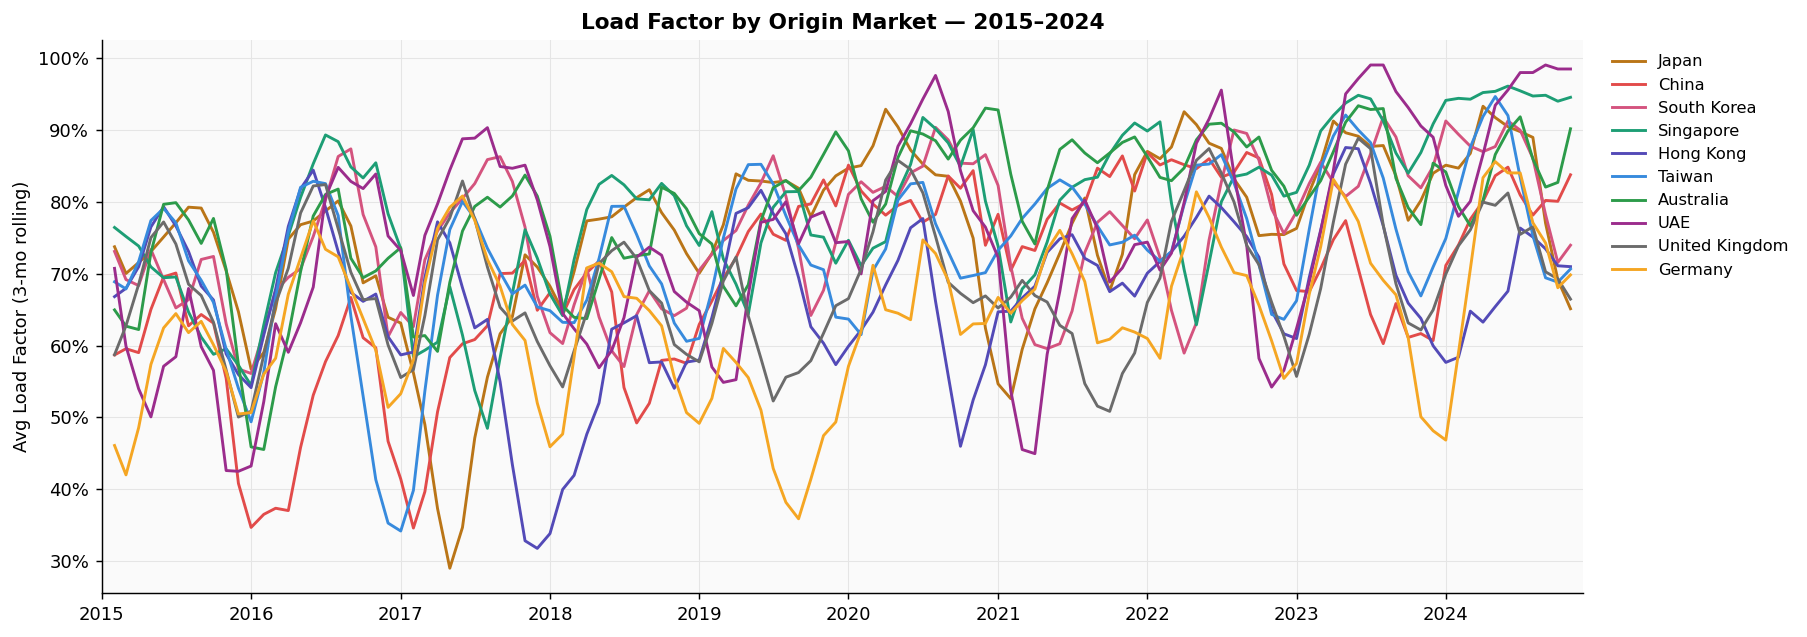

In [4]:
monthly_lf = (
    df.groupby(["date", "market_country", "market_country_name"])["load_factor"]
    .mean()
    .reset_index()
)

markets = df["market_country"].unique()
fig, ax = plt.subplots(figsize=(14, 5))

for mkt in markets:
    sub = monthly_lf[monthly_lf["market_country"] == mkt]
    name = sub["market_country_name"].iloc[0]
    color = MARKET_COLORS.get(mkt, "#999")
    # Smoothed line (3-month rolling)
    vals = sub.set_index("date")["load_factor"].rolling(3, center=True).mean()
    ax.plot(vals.index, vals.values, color=color, linewidth=1.6, label=name)

ax.yaxis.set_major_formatter(mtick.FuncFormatter(pct_fmt))
ax.set_ylabel("Avg Load Factor (3-mo rolling)")
ax.set_title("Load Factor by Origin Market — 2015–2024")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
ax.set_xlim(monthly_lf["date"].min(), monthly_lf["date"].max())
plt.tight_layout()
plt.show()


### 2b. Average load factor by market (box plot)

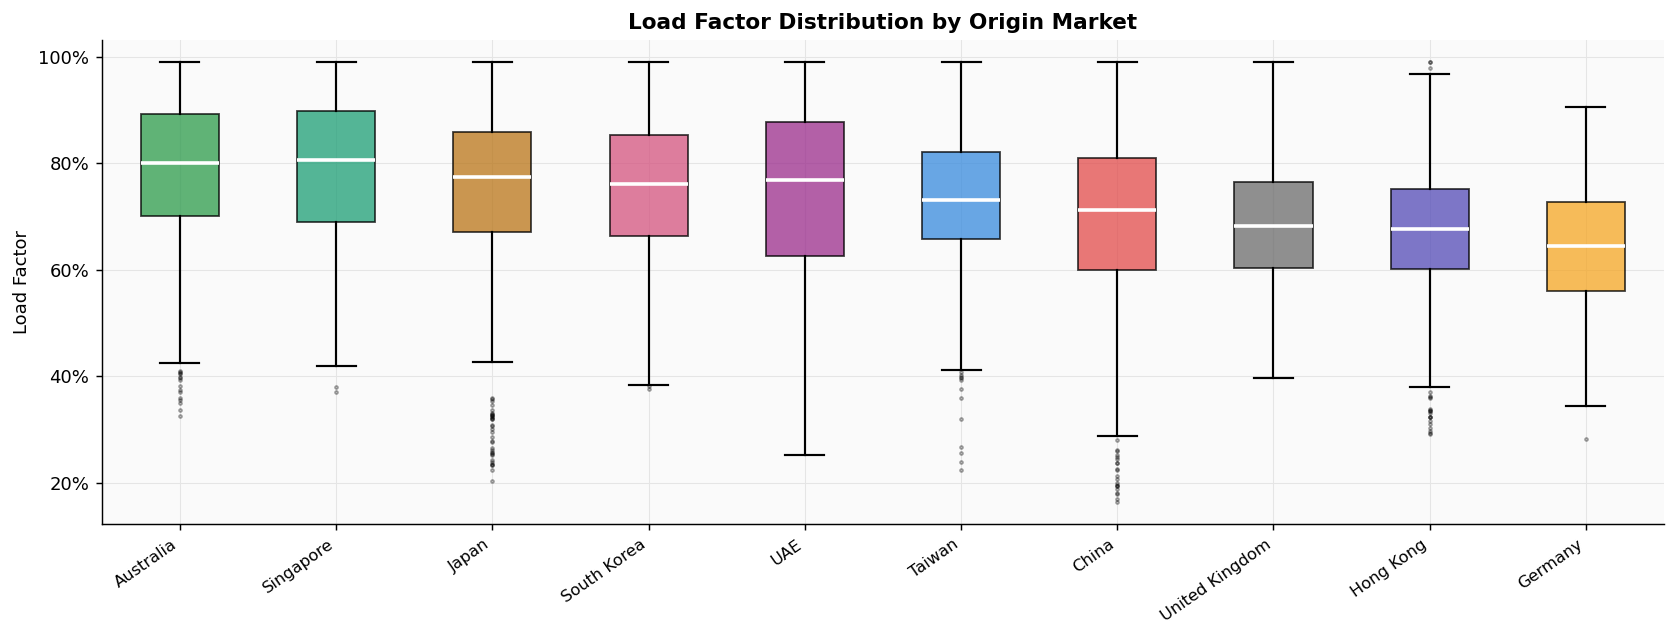

In [5]:
order = (df.groupby("market_country_name")["load_factor"]
           .mean().sort_values(ascending=False).index.tolist())

fig, ax = plt.subplots(figsize=(13, 5))
data_by_market = [df[df["market_country_name"] == m]["load_factor"].values for m in order]
colors_box = [MARKET_COLORS.get(
    df[df["market_country_name"] == m]["market_country"].iloc[0], "#999"
) for m in order]

bp = ax.boxplot(data_by_market, patch_artist=True, notch=False,
                medianprops=dict(color="white", linewidth=2),
                whiskerprops=dict(linewidth=1.2),
                capprops=dict(linewidth=1.2),
                flierprops=dict(marker=".", markersize=3, alpha=0.4))

for patch, color in zip(bp["boxes"], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_xticks(range(1, len(order) + 1))
ax.set_xticklabels(order, rotation=35, ha="right", fontsize=9)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(pct_fmt))
ax.set_ylabel("Load Factor")
ax.set_title("Load Factor Distribution by Origin Market")
plt.tight_layout()
plt.show()


### 2c. Monthly seasonality by market

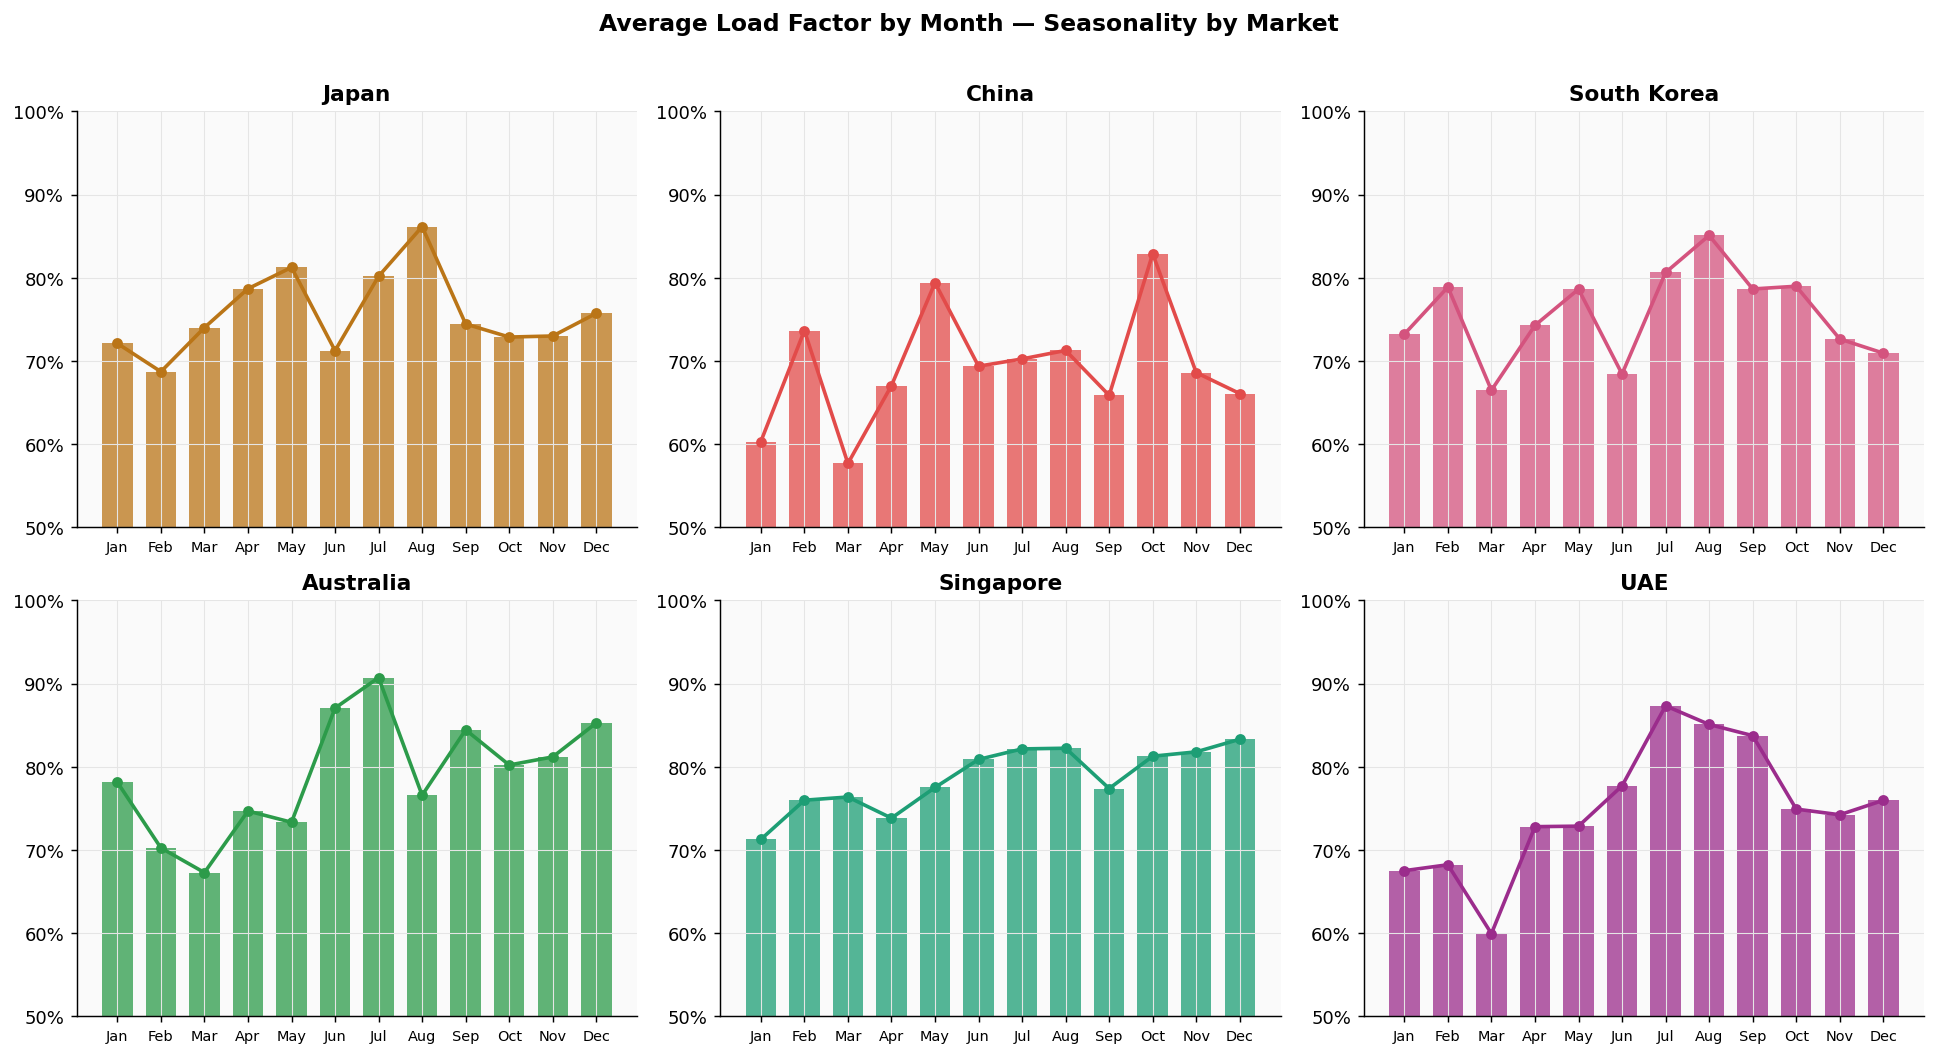

In [6]:
MONTH_LABELS = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]

seasonal = (
    df.groupby(["market_country", "market_country_name", "month"])["load_factor"]
    .mean()
    .reset_index()
)

focus_markets = ["JP", "CN", "KR", "AU", "SG", "AE"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=False)

for ax, mkt in zip(axes.flat, focus_markets):
    sub = seasonal[seasonal["market_country"] == mkt].sort_values("month")
    name = sub["market_country_name"].iloc[0] if len(sub) else mkt
    color = MARKET_COLORS.get(mkt, "#999")

    ax.bar(sub["month"], sub["load_factor"], color=color, alpha=0.75, width=0.7)
    ax.plot(sub["month"], sub["load_factor"], color=color, linewidth=2, marker="o", markersize=5)

    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(MONTH_LABELS, fontsize=8)
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(pct_fmt))
    ax.set_title(name)
    ax.set_ylim(0.5, 1.0)

fig.suptitle("Average Load Factor by Month — Seasonality by Market", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


### 2d. Top 15 routes by average load factor

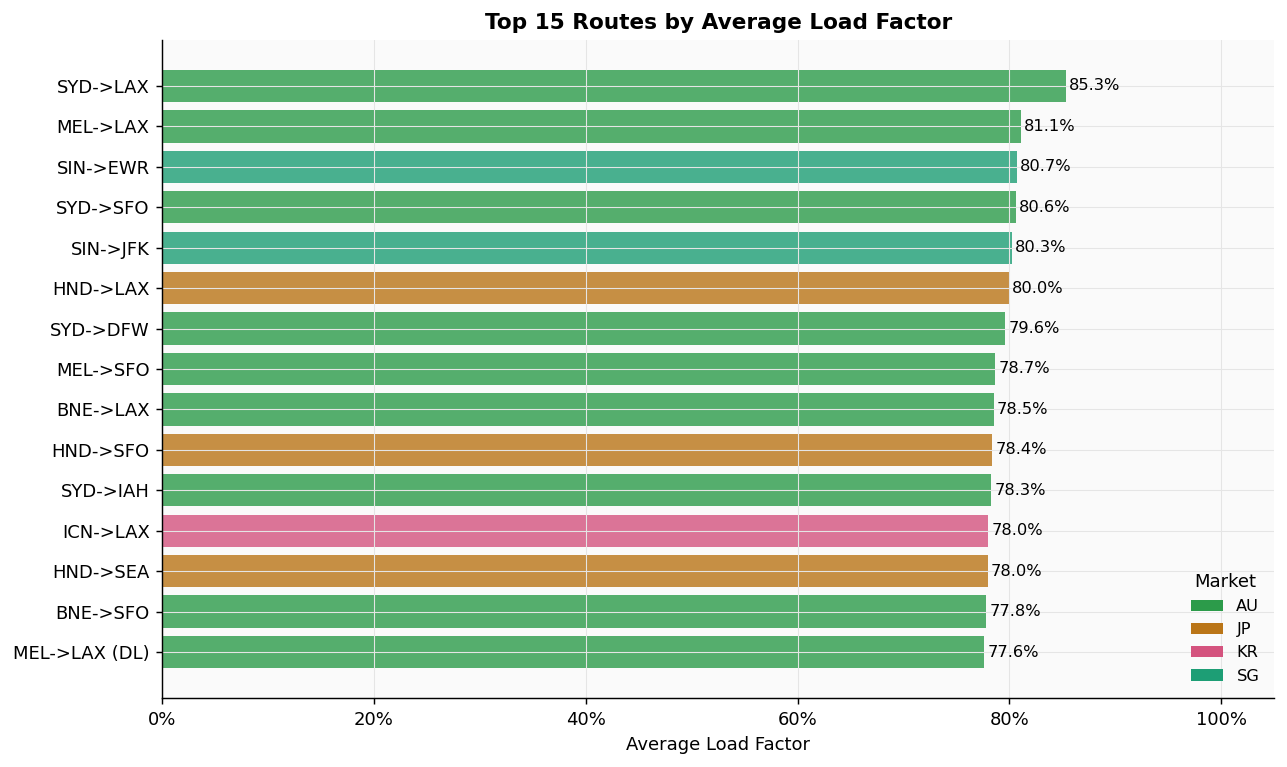

In [7]:
route_lf = (
    df.groupby(["flight_od", "market_country", "aircraft_type"])["load_factor"]
    .mean()
    .reset_index()
    .sort_values("load_factor", ascending=True)
    .tail(15)
)

fig, ax = plt.subplots(figsize=(10, 6))
colors = [MARKET_COLORS.get(m, "#999") for m in route_lf["market_country"]]
bars = ax.barh(route_lf["flight_od"], route_lf["load_factor"], color=colors, alpha=0.8)

for bar, val in zip(bars, route_lf["load_factor"]):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height() / 2,
            f"{val:.1%}", va="center", fontsize=9)

ax.xaxis.set_major_formatter(mtick.FuncFormatter(pct_fmt))
ax.set_xlabel("Average Load Factor")
ax.set_title("Top 15 Routes by Average Load Factor")
ax.set_xlim(0, 1.05)

# Legend for market colours
from matplotlib.patches import Patch
seen = {}
for mkt, color in zip(route_lf["market_country"], colors):
    if mkt not in seen:
        seen[mkt] = color
handles = [Patch(facecolor=c, label=k) for k, c in seen.items()]
ax.legend(handles=handles, title="Market", loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()


### 2e. Connecting vs direct load factor over time

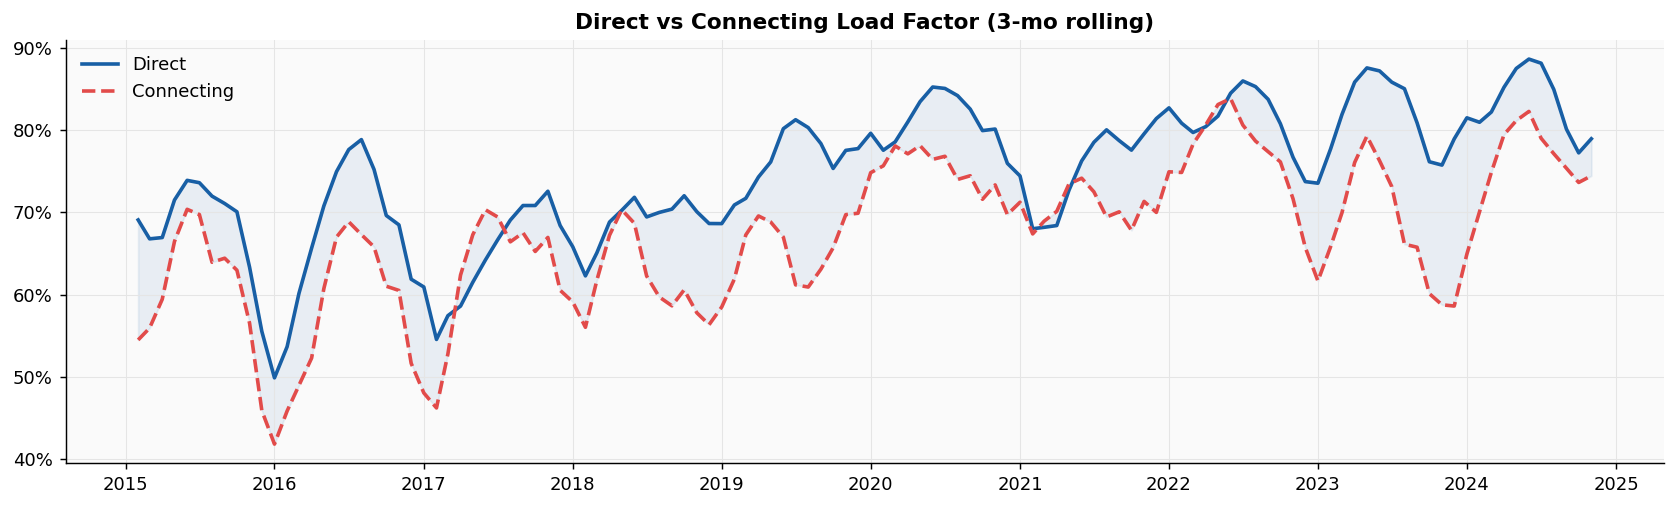

In [8]:
conn_lf = (
    df.groupby(["date", "is_connecting"])["load_factor"]
    .mean()
    .unstack()
    .rolling(3, center=True)
    .mean()
)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(conn_lf.index, conn_lf[0], color="#185FA5", linewidth=2, label="Direct")
ax.plot(conn_lf.index, conn_lf[1], color="#E24B4A", linewidth=2, linestyle="--", label="Connecting")
ax.fill_between(conn_lf.index, conn_lf[0], conn_lf[1], alpha=0.08, color="#185FA5")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(pct_fmt))
ax.set_title("Direct vs Connecting Load Factor (3-mo rolling)")
ax.legend()
plt.tight_layout()
plt.show()


---
## 3. Yield & Revenue

### 3a. Economy yield over time by market

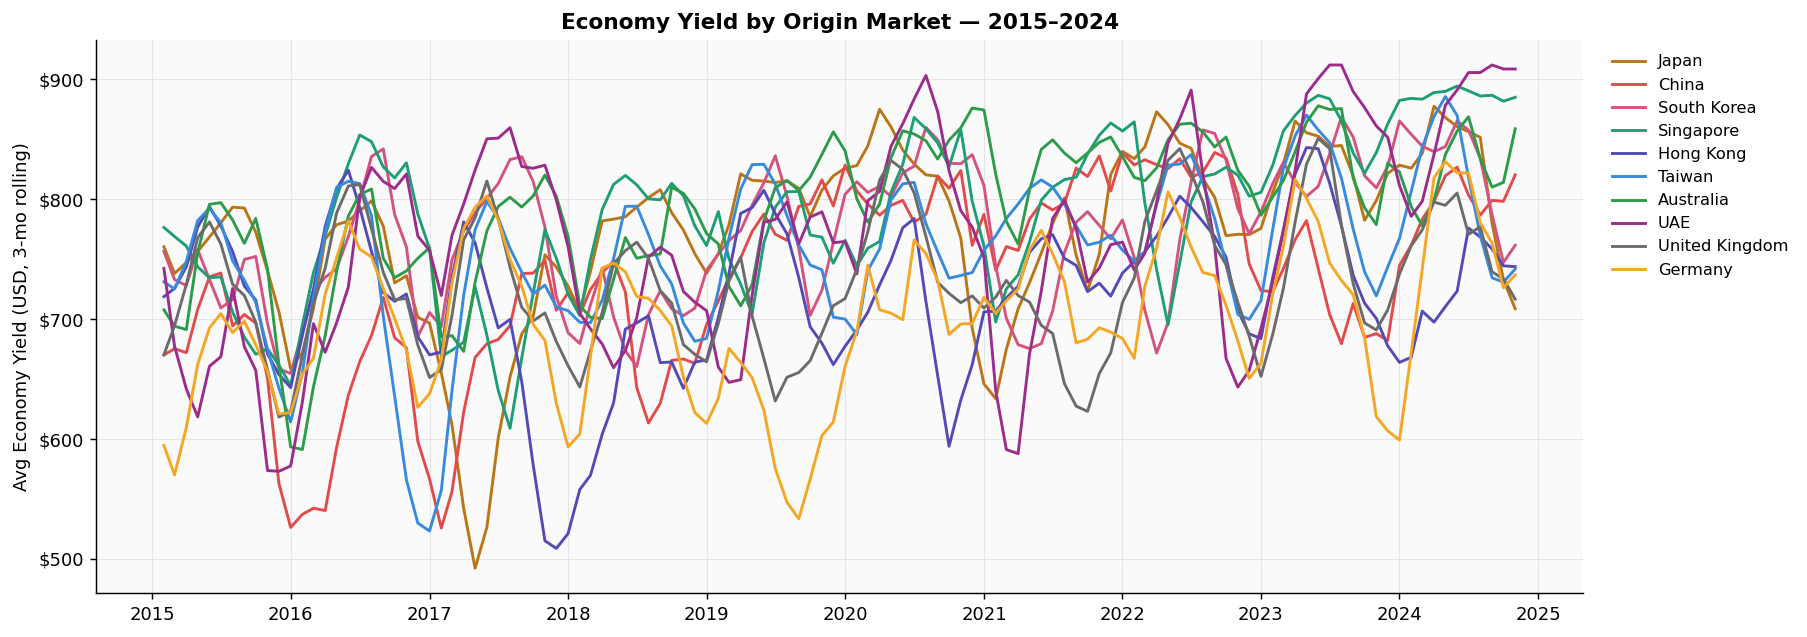

In [9]:
monthly_yield = (
    df.groupby(["date", "market_country", "market_country_name"])["yield_economy_usd"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 5))
for mkt in markets:
    sub = monthly_yield[monthly_yield["market_country"] == mkt]
    name = sub["market_country_name"].iloc[0]
    vals = sub.set_index("date")["yield_economy_usd"].rolling(3, center=True).mean()
    ax.plot(vals.index, vals.values, color=MARKET_COLORS.get(mkt, "#999"),
            linewidth=1.6, label=name)

ax.yaxis.set_major_formatter(mtick.FuncFormatter(usd_fmt))
ax.set_ylabel("Avg Economy Yield (USD, 3-mo rolling)")
ax.set_title("Economy Yield by Origin Market — 2015–2024")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()


### 3b. Cabin yield comparison — all routes

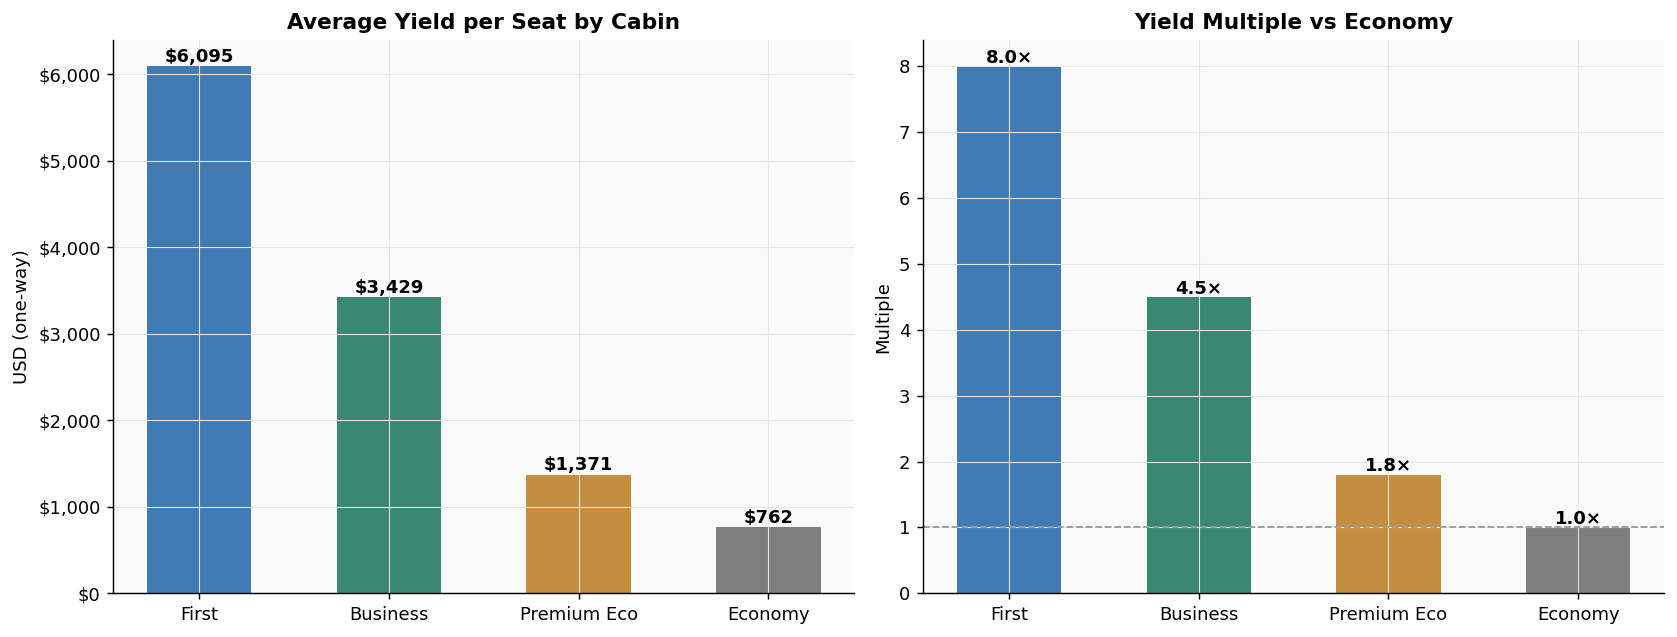

In [10]:
cabin_yields = df[["yield_first_usd", "yield_business_usd",
                   "yield_premium_eco_usd", "yield_economy_usd"]].mean()
cabin_labels = ["First", "Business", "Premium Eco", "Economy"]
cabin_colors = [CABIN_COLORS[k] for k in ["first", "business", "premium_eco", "economy"]]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart — absolute yields
ax = axes[0]
bars = ax.bar(cabin_labels, cabin_yields.values, color=cabin_colors, alpha=0.82, width=0.55)
for bar, val in zip(bars, cabin_yields.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            f"\${val:,.0f}", ha="center", fontsize=10, fontweight="bold")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(usd_fmt))
ax.set_title("Average Yield per Seat by Cabin")
ax.set_ylabel("USD (one-way)")

# Multipliers relative to economy
ax2 = axes[1]
mult = cabin_yields / cabin_yields["yield_economy_usd"]
bars2 = ax2.bar(cabin_labels, mult.values, color=cabin_colors, alpha=0.82, width=0.55)
ax2.axhline(1.0, color="#999", linestyle="--", linewidth=1)
for bar, val in zip(bars2, mult.values):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
             f"{val:.1f}×", ha="center", fontsize=10, fontweight="bold")
ax2.set_title("Yield Multiple vs Economy")
ax2.set_ylabel("Multiple")

plt.tight_layout()
plt.show()


### 3c. Annual revenue by market

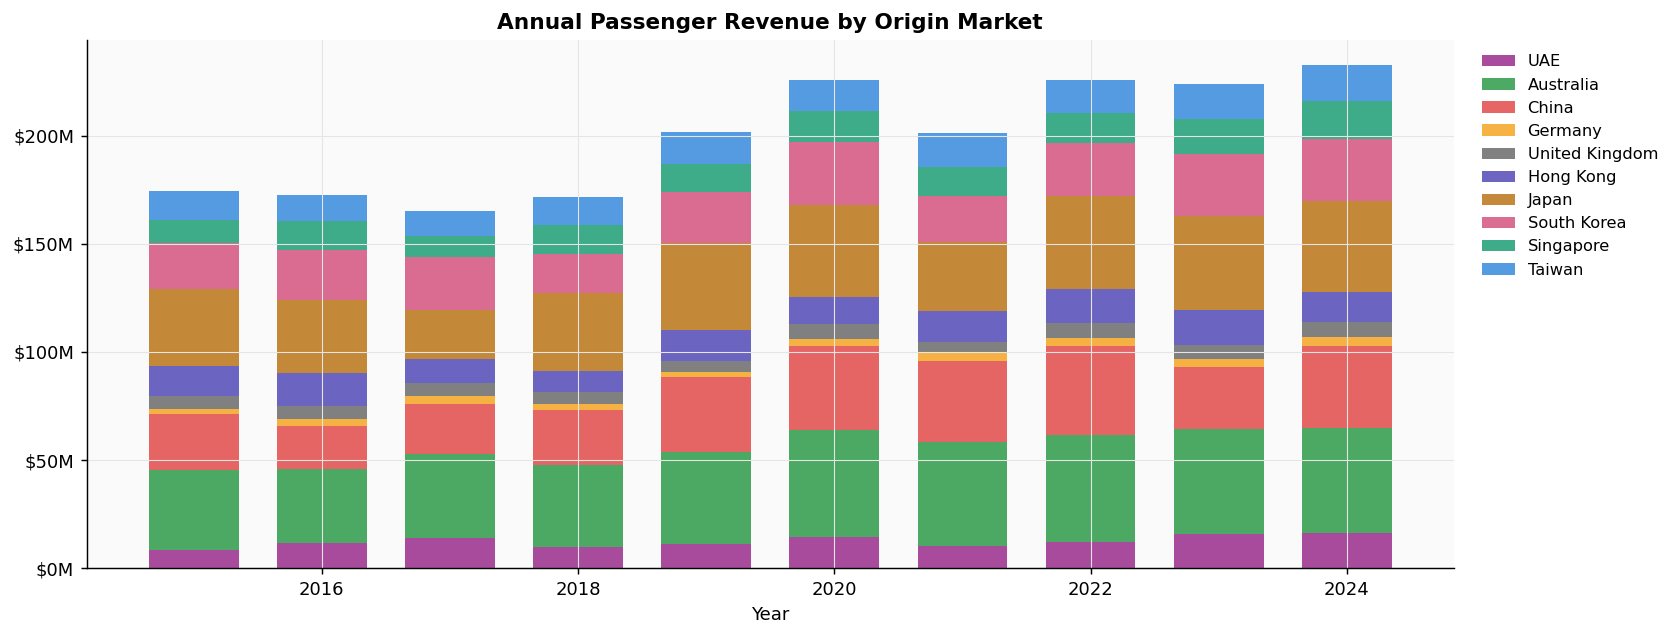

In [11]:
annual_rev = (
    df.groupby(["year", "market_country", "market_country_name"])["revenue_usd"]
    .sum()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 5))
bottom = np.zeros(len(annual_rev["year"].unique()))
years = sorted(annual_rev["year"].unique())

for mkt in sorted(annual_rev["market_country"].unique()):
    sub = annual_rev[annual_rev["market_country"] == mkt].sort_values("year")
    vals = sub.set_index("year").reindex(years)["revenue_usd"].fillna(0).values / 1e6
    name = sub["market_country_name"].iloc[0]
    ax.bar(years, vals, bottom=bottom, color=MARKET_COLORS.get(mkt, "#999"),
           alpha=0.85, label=name, width=0.7)
    bottom += vals

ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"\${x:,.0f}M"))
ax.set_xlabel("Year")
ax.set_title("Annual Passenger Revenue by Origin Market")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()


### 3d. RASK by route

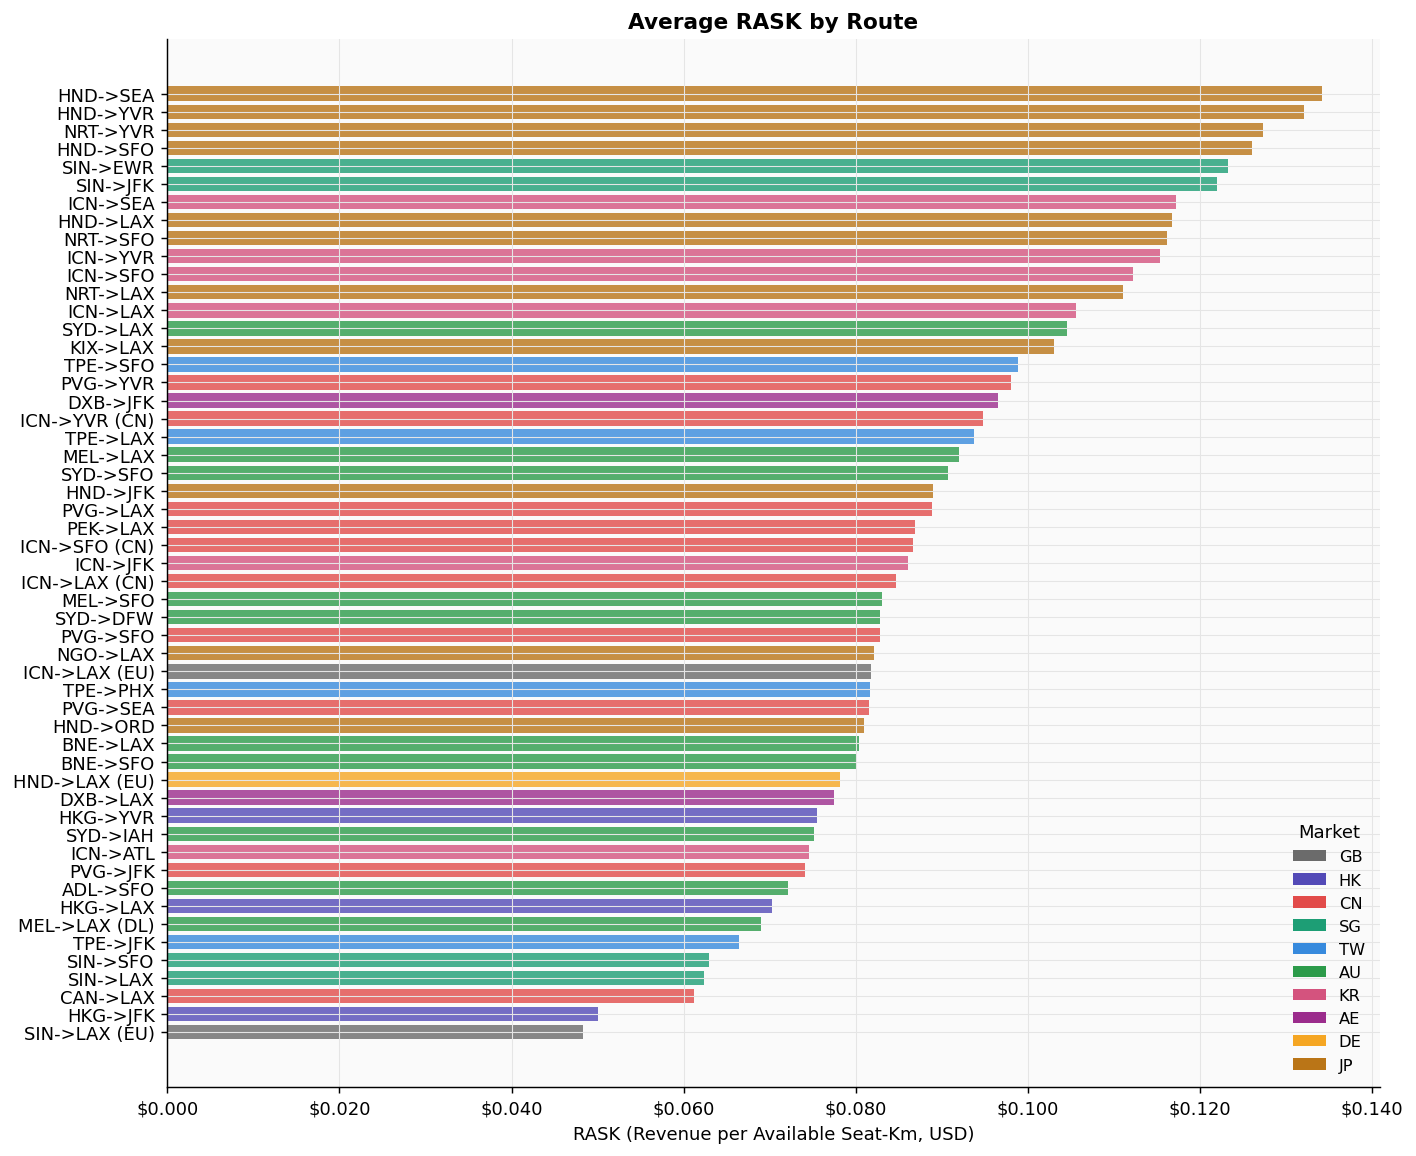

In [12]:
route_rask = (
    df.groupby(["flight_od", "market_country"])["rask_usd"]
    .mean()
    .reset_index()
    .sort_values("rask_usd", ascending=True)
)

fig, ax = plt.subplots(figsize=(11, 9))
colors = [MARKET_COLORS.get(m, "#999") for m in route_rask["market_country"]]
ax.barh(route_rask["flight_od"], route_rask["rask_usd"], color=colors, alpha=0.8)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"\${x:.3f}"))
ax.set_xlabel("RASK (Revenue per Available Seat-Km, USD)")
ax.set_title("Average RASK by Route")

from matplotlib.patches import Patch
seen = {}
for mkt, color in zip(route_rask["market_country"], colors):
    if mkt not in seen: seen[mkt] = color
handles = [Patch(facecolor=c, label=k) for k, c in seen.items()]
ax.legend(handles=handles, title="Market", fontsize=9)
plt.tight_layout()
plt.show()


### 3e. Direct vs connecting yield gap

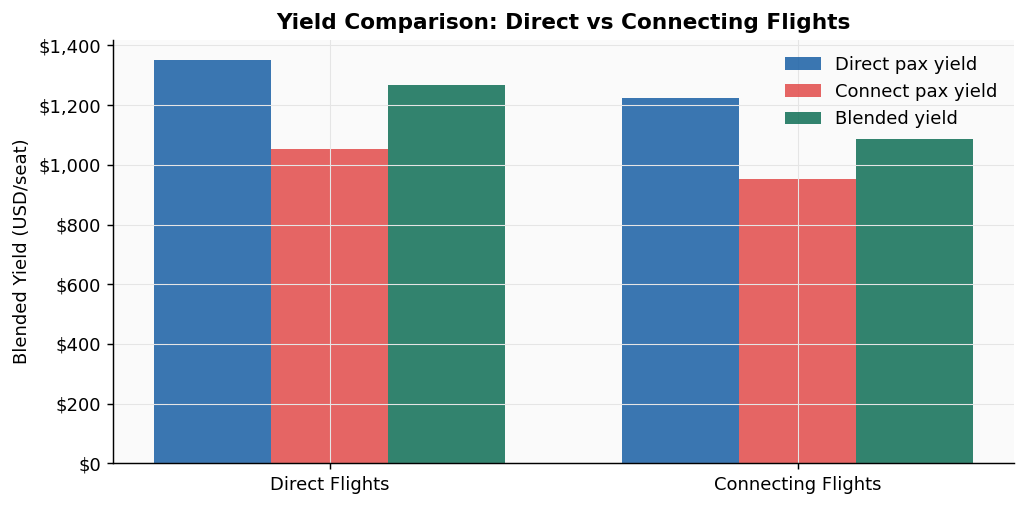

In [13]:
yield_comp = (
    df.groupby("is_connecting")[["yield_direct_blended", "yield_connect_blended",
                                  "yield_overall_blended"]].mean()
)

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(2)
width = 0.25
labels = ["Direct Flights", "Connecting Flights"]

b1 = ax.bar(x - width, yield_comp["yield_direct_blended"].values,
            width, label="Direct pax yield", color="#185FA5", alpha=0.85)
b2 = ax.bar(x,          yield_comp["yield_connect_blended"].values,
            width, label="Connect pax yield", color="#E24B4A", alpha=0.85)
b3 = ax.bar(x + width,  yield_comp["yield_overall_blended"].values,
            width, label="Blended yield", color="#0F6E56", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(usd_fmt))
ax.set_title("Yield Comparison: Direct vs Connecting Flights")
ax.set_ylabel("Blended Yield (USD/seat)")
ax.legend()
plt.tight_layout()
plt.show()


---
## 4. Fuel

### 4a. Fuel price path (OU process)

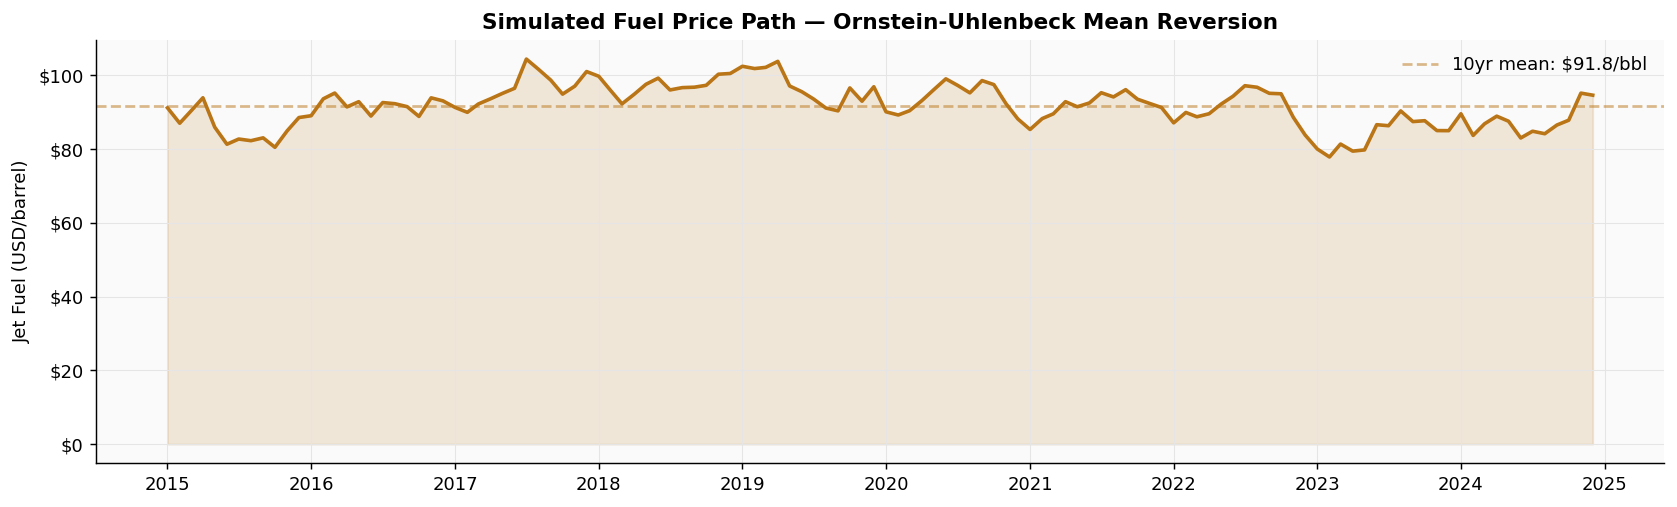

In [14]:
fuel_monthly = df.groupby("date")["fuel_price_usd_bbl"].mean().reset_index()

fig, ax = plt.subplots(figsize=(13, 4))
ax.fill_between(fuel_monthly["date"], fuel_monthly["fuel_price_usd_bbl"],
                alpha=0.15, color="#BA7517")
ax.plot(fuel_monthly["date"], fuel_monthly["fuel_price_usd_bbl"],
        color="#BA7517", linewidth=2)

mean_price = fuel_monthly["fuel_price_usd_bbl"].mean()
ax.axhline(mean_price, color="#BA7517", linestyle="--", alpha=0.5,
           label=f"10yr mean: \${mean_price:.1f}/bbl")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"\${x:.0f}"))
ax.set_ylabel("Jet Fuel (USD/barrel)")
ax.set_title("Simulated Fuel Price Path — Ornstein-Uhlenbeck Mean Reversion")
ax.legend()
plt.tight_layout()
plt.show()


### 4b. Fuel cost per flight by route

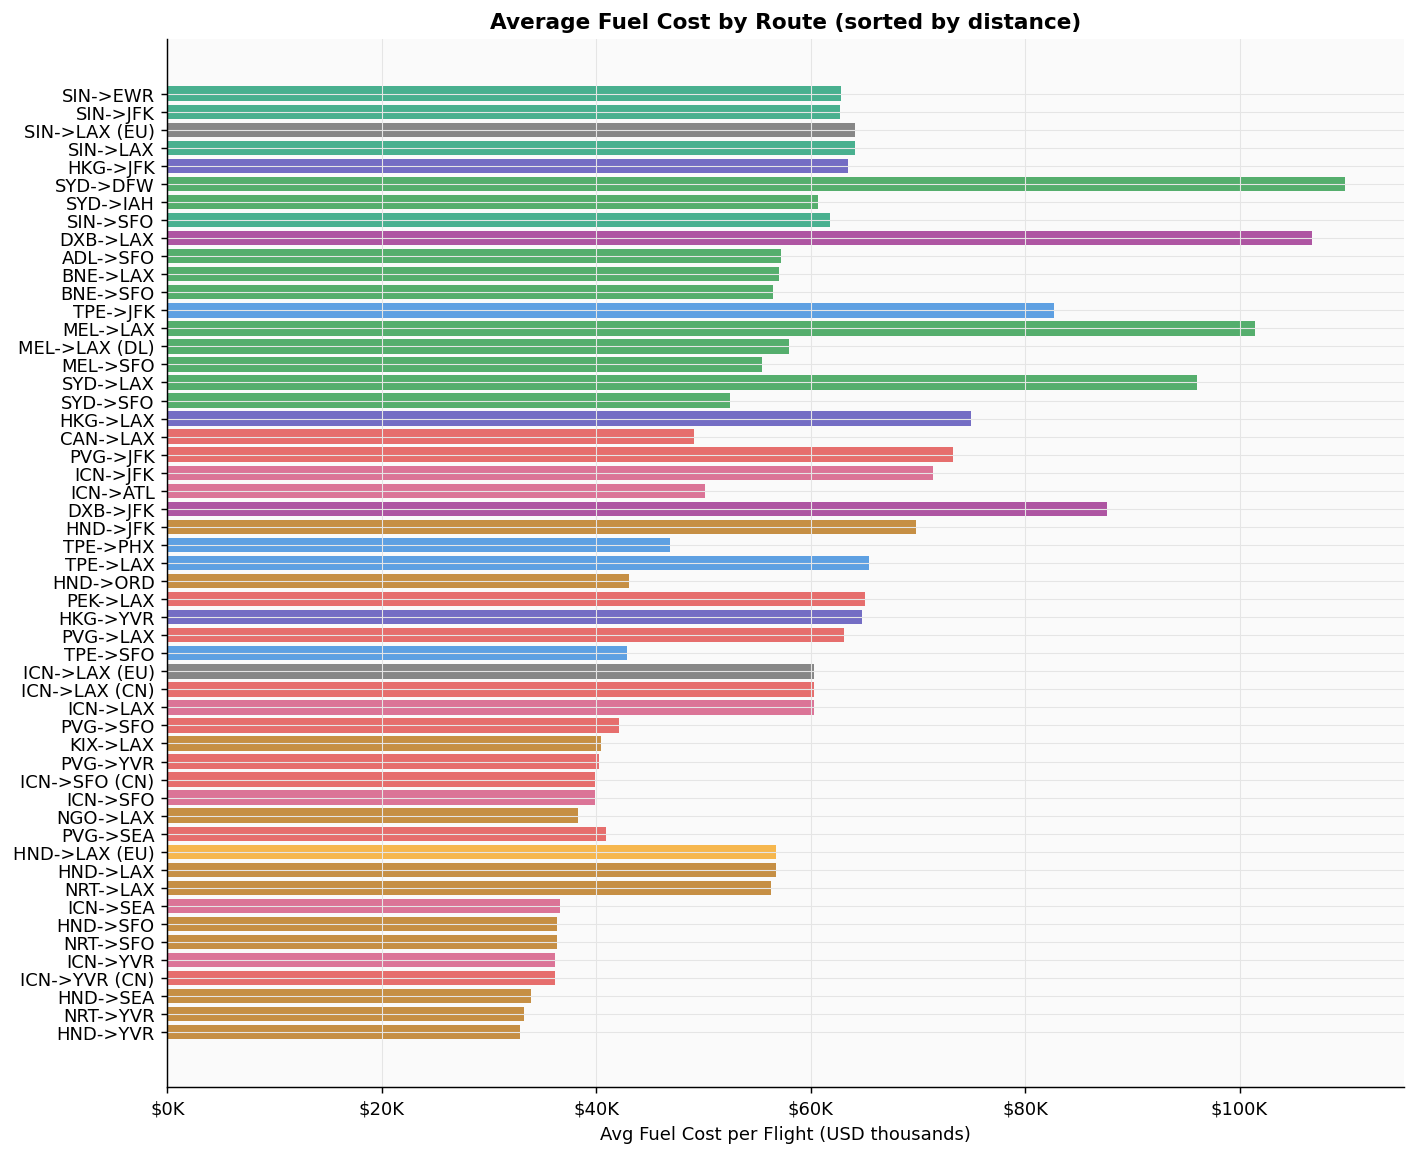

In [15]:
route_fuel = (
    df.groupby(["flight_od", "market_country", "distance_km"])["fuel_cost_usd"]
    .mean()
    .reset_index()
    .sort_values("distance_km")
)

fig, ax = plt.subplots(figsize=(11, 9))
colors = [MARKET_COLORS.get(m, "#999") for m in route_fuel["market_country"]]
ax.barh(route_fuel["flight_od"], route_fuel["fuel_cost_usd"] / 1e3,
        color=colors, alpha=0.8)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"\${x:.0f}K"))
ax.set_xlabel("Avg Fuel Cost per Flight (USD thousands)")
ax.set_title("Average Fuel Cost by Route (sorted by distance)")
plt.tight_layout()
plt.show()


### 4c. Fuel cost vs distance — scatter

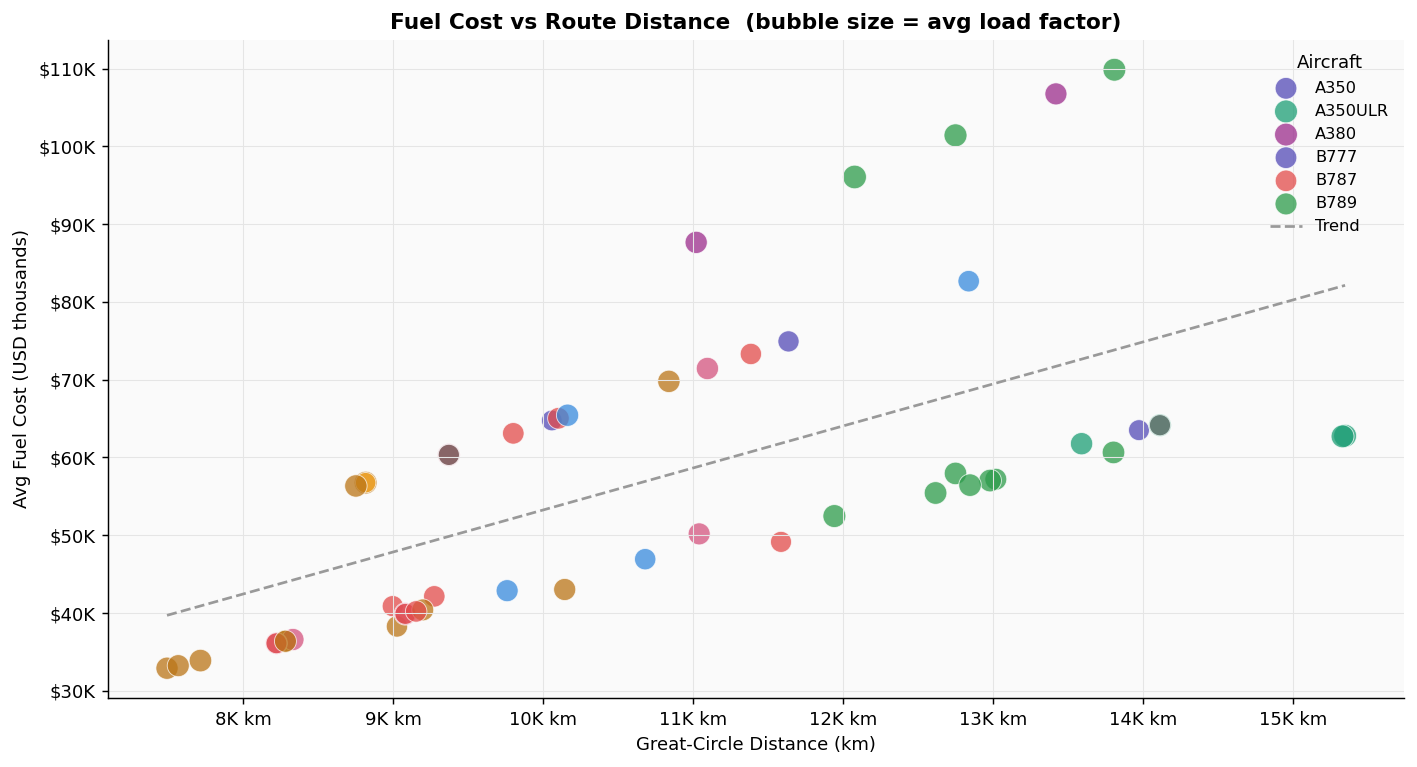

In [16]:
route_agg = (
    df.groupby(["flight_od", "market_country", "aircraft_type", "distance_km"])
    .agg(avg_fuel_cost=("fuel_cost_usd", "mean"),
         avg_lf=("load_factor", "mean"))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 6))
for aircraft, grp in route_agg.groupby("aircraft_type"):
    colors_scatter = [MARKET_COLORS.get(m, "#999") for m in grp["market_country"]]
    sc = ax.scatter(grp["distance_km"], grp["avg_fuel_cost"] / 1e3,
                    c=colors_scatter, s=grp["avg_lf"] * 200,
                    alpha=0.75, label=aircraft, marker="o",
                    edgecolors="white", linewidths=0.5)

# Trendline
z = np.polyfit(route_agg["distance_km"], route_agg["avg_fuel_cost"] / 1e3, 1)
xline = np.linspace(route_agg["distance_km"].min(), route_agg["distance_km"].max(), 100)
ax.plot(xline, np.polyval(z, xline), "--", color="#999", linewidth=1.5, label="Trend")

ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K km"))
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"\${x:.0f}K"))
ax.set_xlabel("Great-Circle Distance (km)")
ax.set_ylabel("Avg Fuel Cost (USD thousands)")
ax.set_title("Fuel Cost vs Route Distance  (bubble size = avg load factor)")
ax.legend(title="Aircraft", fontsize=9)
plt.tight_layout()
plt.show()


### 4d. Fuel as % of revenue — by market

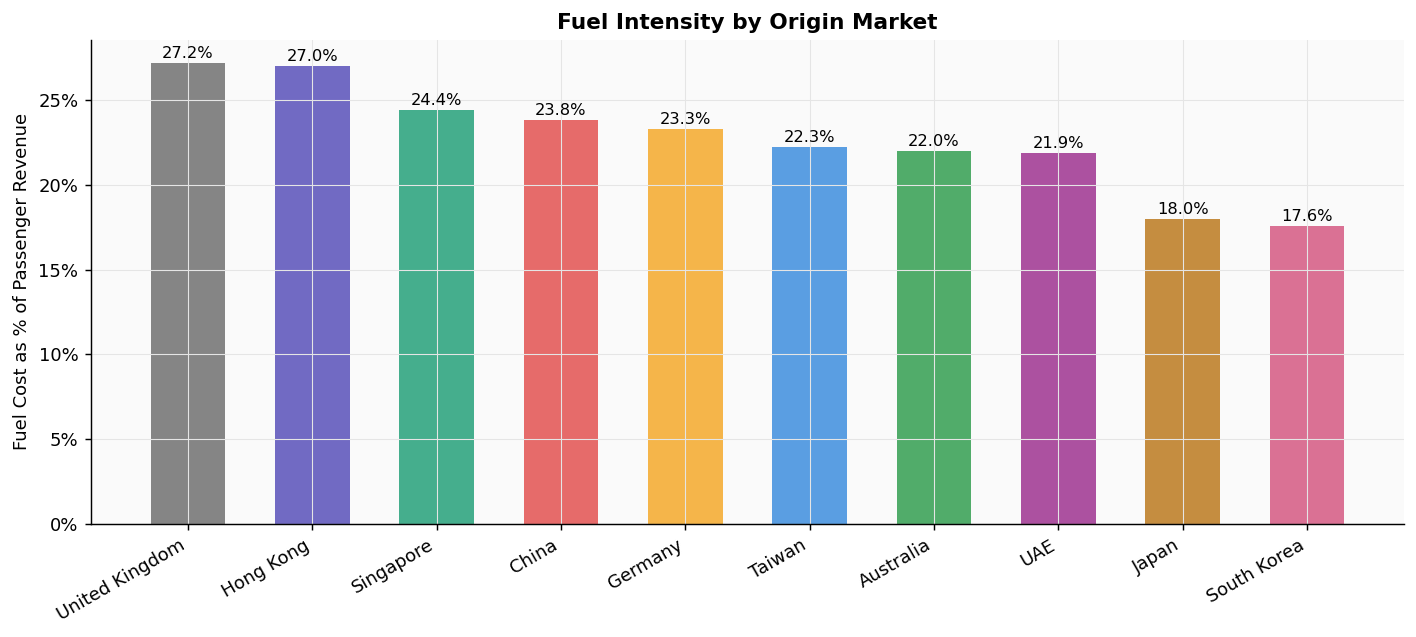

In [17]:
fuel_pct = (
    df.groupby("market_country_name")["fuel_pct_revenue"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
colors_fp = [MARKET_COLORS.get(
    df[df["market_country_name"] == n]["market_country"].iloc[0], "#999"
) for n in fuel_pct["market_country_name"]]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(fuel_pct["market_country_name"], fuel_pct["fuel_pct_revenue"],
              color=colors_fp, alpha=0.82, width=0.6)
for bar, val in zip(bars, fuel_pct["fuel_pct_revenue"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f"{val:.1%}", ha="center", fontsize=9)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(pct_fmt))
ax.set_ylabel("Fuel Cost as % of Passenger Revenue")
ax.set_title("Fuel Intensity by Origin Market")
ax.set_xticklabels(fuel_pct["market_country_name"], rotation=30, ha="right")
plt.tight_layout()
plt.show()


---
## 5. Passenger Payload

### 5a. Payload over time

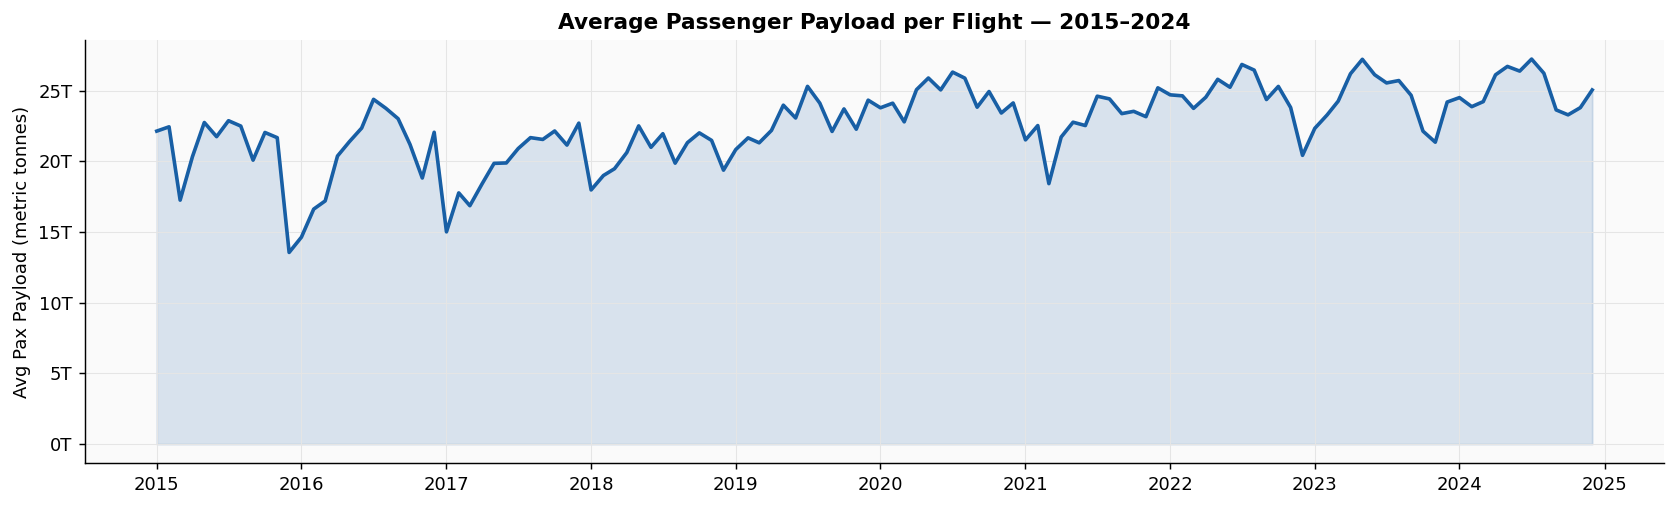

In [18]:
payload_monthly = df.groupby("date")["pax_payload_kg"].mean().reset_index()

fig, ax = plt.subplots(figsize=(13, 4))
ax.fill_between(payload_monthly["date"], payload_monthly["pax_payload_kg"] / 1e3,
                alpha=0.15, color="#185FA5")
ax.plot(payload_monthly["date"], payload_monthly["pax_payload_kg"] / 1e3,
        color="#185FA5", linewidth=2)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:.0f}T"))
ax.set_ylabel("Avg Pax Payload (metric tonnes)")
ax.set_title("Average Passenger Payload per Flight — 2015–2024")
plt.tight_layout()
plt.show()


### 5b. Payload by aircraft type

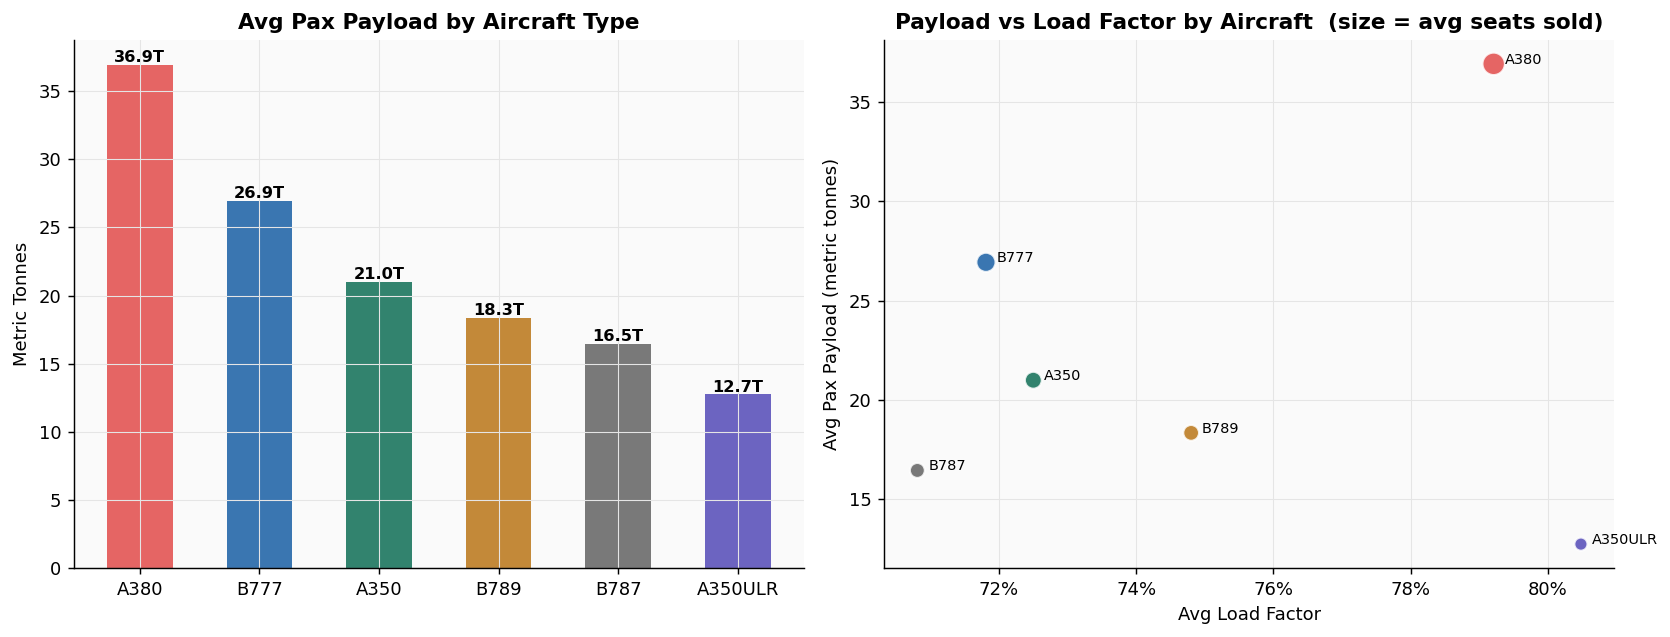

In [19]:
payload_ac = (
    df.groupby("aircraft_type")
    .agg(avg_payload=("pax_payload_kg", "mean"),
         avg_seats=("seats_sold", "mean"),
         avg_lf=("load_factor", "mean"),
         n_routes=("flight_od", "nunique"))
    .reset_index()
    .sort_values("avg_payload", ascending=False)
)

AIRCRAFT_COLORS = {
    "A380": "#E24B4A", "B777": "#185FA5", "A350": "#0F6E56",
    "A350ULR": "#534AB7", "B789": "#BA7517", "B787": "#636363"
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
colors_ac = [AIRCRAFT_COLORS.get(a, "#999") for a in payload_ac["aircraft_type"]]
bars = ax.bar(payload_ac["aircraft_type"], payload_ac["avg_payload"] / 1e3,
              color=colors_ac, alpha=0.85, width=0.55)
for bar, val in zip(bars, payload_ac["avg_payload"] / 1e3):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
            f"{val:.1f}T", ha="center", fontsize=9, fontweight="bold")
ax.set_title("Avg Pax Payload by Aircraft Type")
ax.set_ylabel("Metric Tonnes")

ax2 = axes[1]
ax2.scatter(payload_ac["avg_lf"], payload_ac["avg_payload"] / 1e3,
            c=colors_ac, s=payload_ac["avg_seats"] * 0.4, alpha=0.85,
            edgecolors="white", linewidths=1.2)
for _, row in payload_ac.iterrows():
    ax2.annotate(row["aircraft_type"],
                 (row["avg_lf"], row["avg_payload"] / 1e3),
                 textcoords="offset points", xytext=(6, 0), fontsize=8)
ax2.xaxis.set_major_formatter(mtick.FuncFormatter(pct_fmt))
ax2.set_xlabel("Avg Load Factor")
ax2.set_ylabel("Avg Pax Payload (metric tonnes)")
ax2.set_title("Payload vs Load Factor by Aircraft  (size = avg seats sold)")

plt.tight_layout()
plt.show()


### 5c. Payload by route — top 20

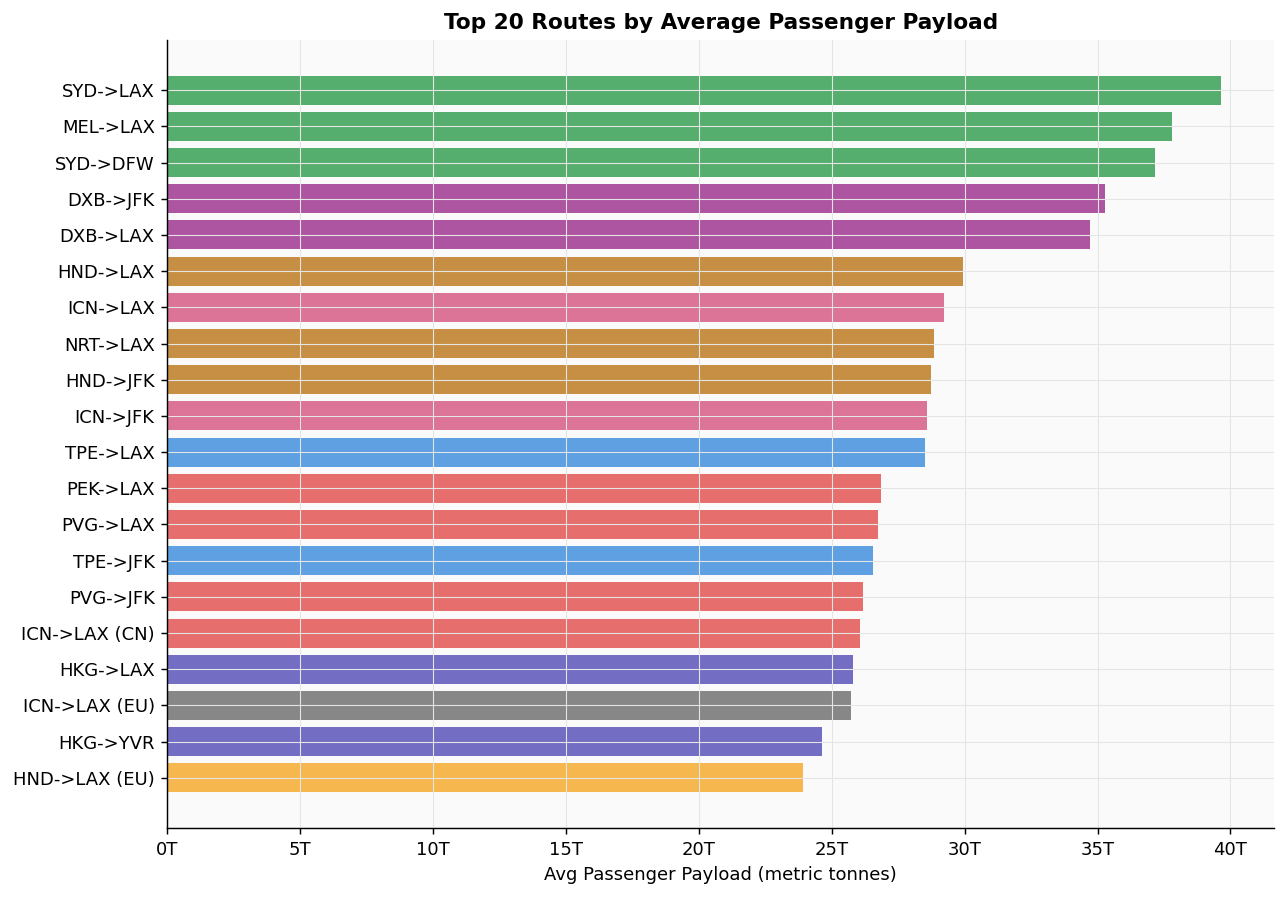

In [20]:
route_payload = (
    df.groupby(["flight_od", "market_country", "distance_km"])["pax_payload_kg"]
    .mean()
    .reset_index()
    .sort_values("pax_payload_kg", ascending=True)
    .tail(20)
)

fig, ax = plt.subplots(figsize=(10, 7))
colors = [MARKET_COLORS.get(m, "#999") for m in route_payload["market_country"]]
ax.barh(route_payload["flight_od"], route_payload["pax_payload_kg"] / 1e3,
        color=colors, alpha=0.8)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:.0f}T"))
ax.set_xlabel("Avg Passenger Payload (metric tonnes)")
ax.set_title("Top 20 Routes by Average Passenger Payload")
plt.tight_layout()
plt.show()


---
## 6. Market Shocks

### 6a. Shock factor timeline by market

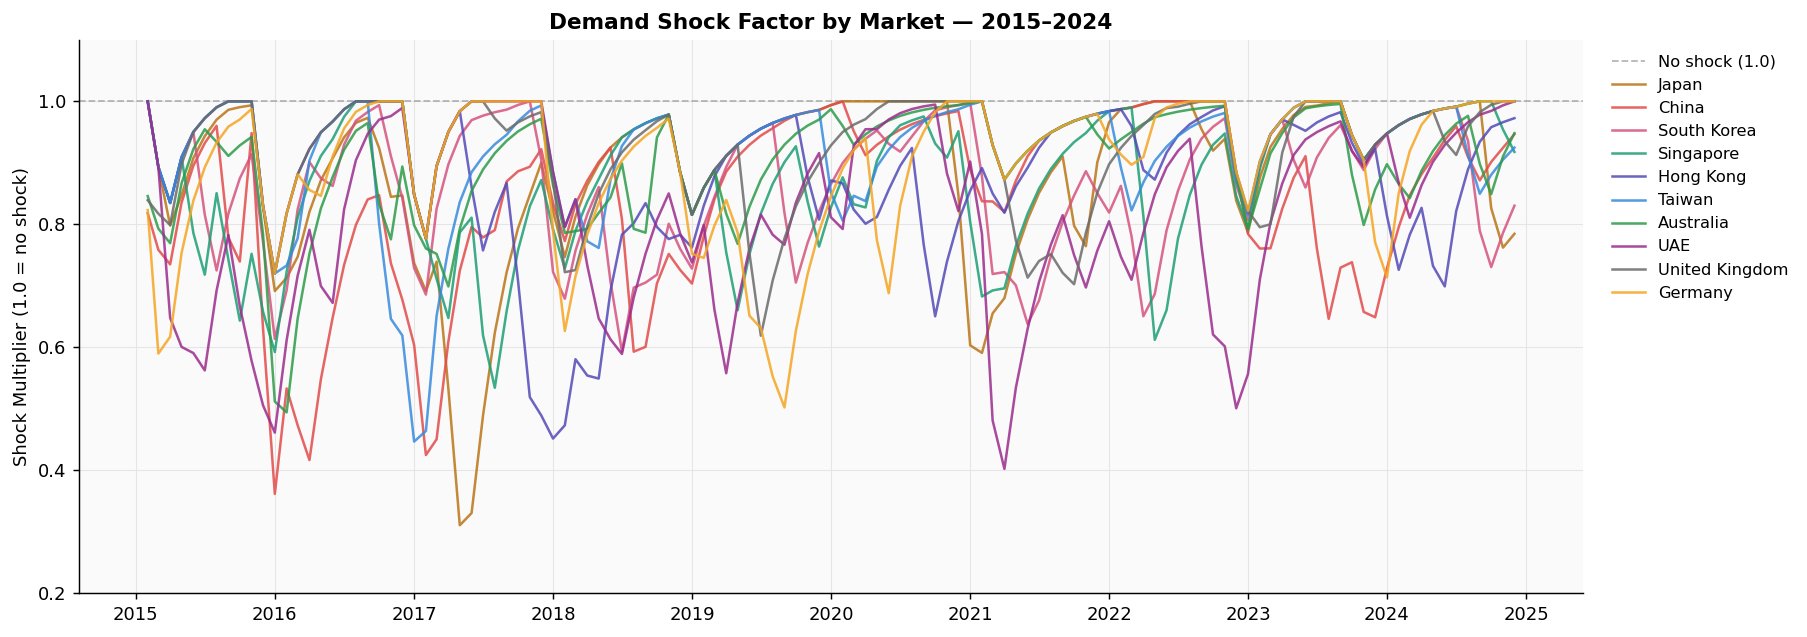

In [21]:
shock_monthly = (
    df.groupby(["date", "market_country", "market_country_name"])["shock_factor"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.axhline(1.0, color="#999", linestyle="--", linewidth=1, alpha=0.7, label="No shock (1.0)")

for mkt in markets:
    sub = shock_monthly[shock_monthly["market_country"] == mkt]
    name = sub["market_country_name"].iloc[0]
    vals = sub.set_index("date")["shock_factor"].rolling(2).mean()
    ax.plot(vals.index, vals.values, color=MARKET_COLORS.get(mkt, "#999"),
            linewidth=1.4, label=name, alpha=0.85)

ax.set_ylabel("Shock Multiplier (1.0 = no shock)")
ax.set_title("Demand Shock Factor by Market — 2015–2024")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
ax.set_ylim(0.2, 1.1)
plt.tight_layout()
plt.show()


### 6b. Shock depth distribution by market

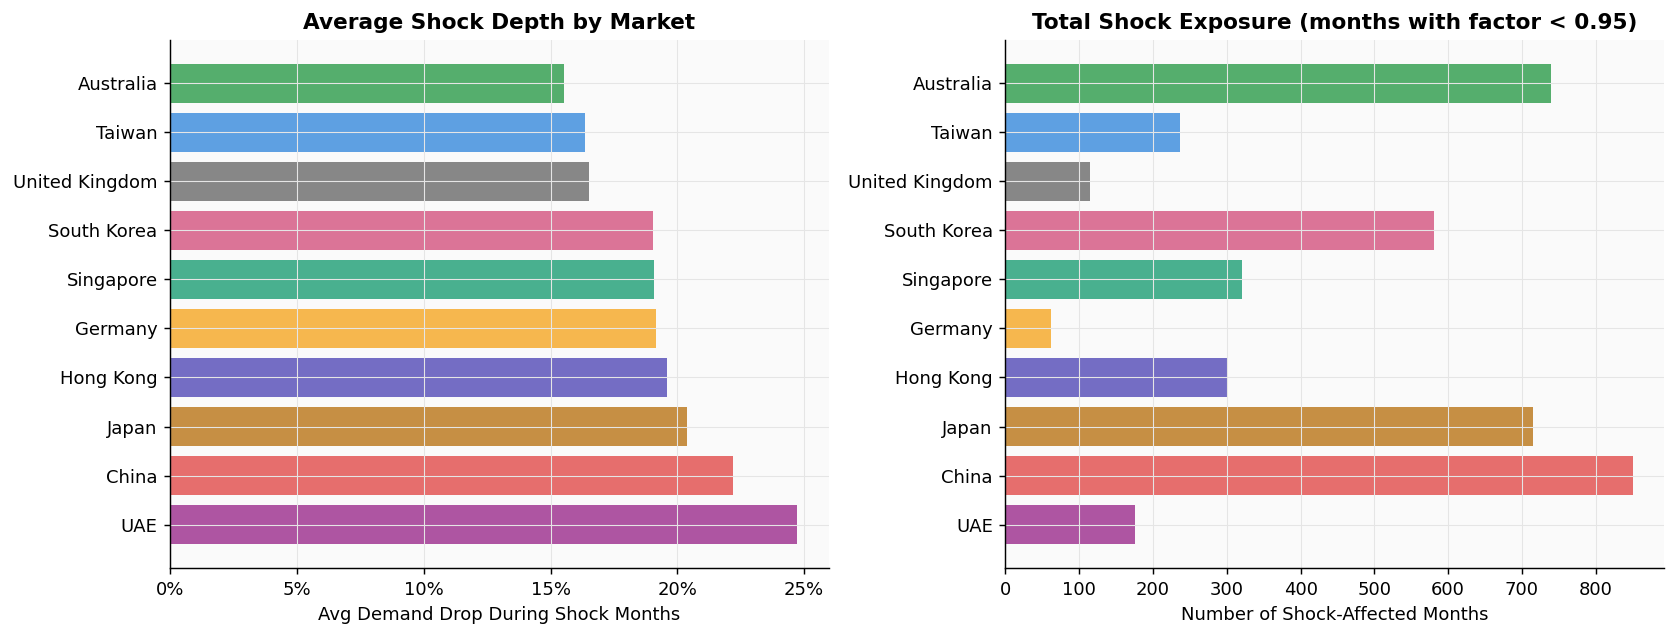

In [22]:
# Only show months where a shock occurred (factor < 0.95)
shocked = df[df["shock_factor"] < 0.95]
shock_depth = (
    shocked.groupby("market_country_name")["shock_factor"]
    .agg(["mean", "min", "count"])
    .rename(columns={"mean": "avg_factor", "min": "worst_factor", "count": "shock_months"})
    .sort_values("avg_factor")
    .reset_index()
)

if len(shock_depth) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    ax = axes[0]
    colors_sd = [MARKET_COLORS.get(
        df[df["market_country_name"] == n]["market_country"].iloc[0], "#999"
    ) for n in shock_depth["market_country_name"]]

    ax.barh(shock_depth["market_country_name"], 1 - shock_depth["avg_factor"],
            color=colors_sd, alpha=0.8, label="Avg shock depth")
    ax.xaxis.set_major_formatter(mtick.FuncFormatter(pct_fmt))
    ax.set_xlabel("Avg Demand Drop During Shock Months")
    ax.set_title("Average Shock Depth by Market")

    ax2 = axes[1]
    ax2.barh(shock_depth["market_country_name"], shock_depth["shock_months"],
             color=colors_sd, alpha=0.8)
    ax2.set_xlabel("Number of Shock-Affected Months")
    ax2.set_title("Total Shock Exposure (months with factor < 0.95)")

    plt.tight_layout()
    plt.show()
else:
    print("No significant shocks recorded in this run.")


### 6c. Impact of shocks on load factor — before vs during

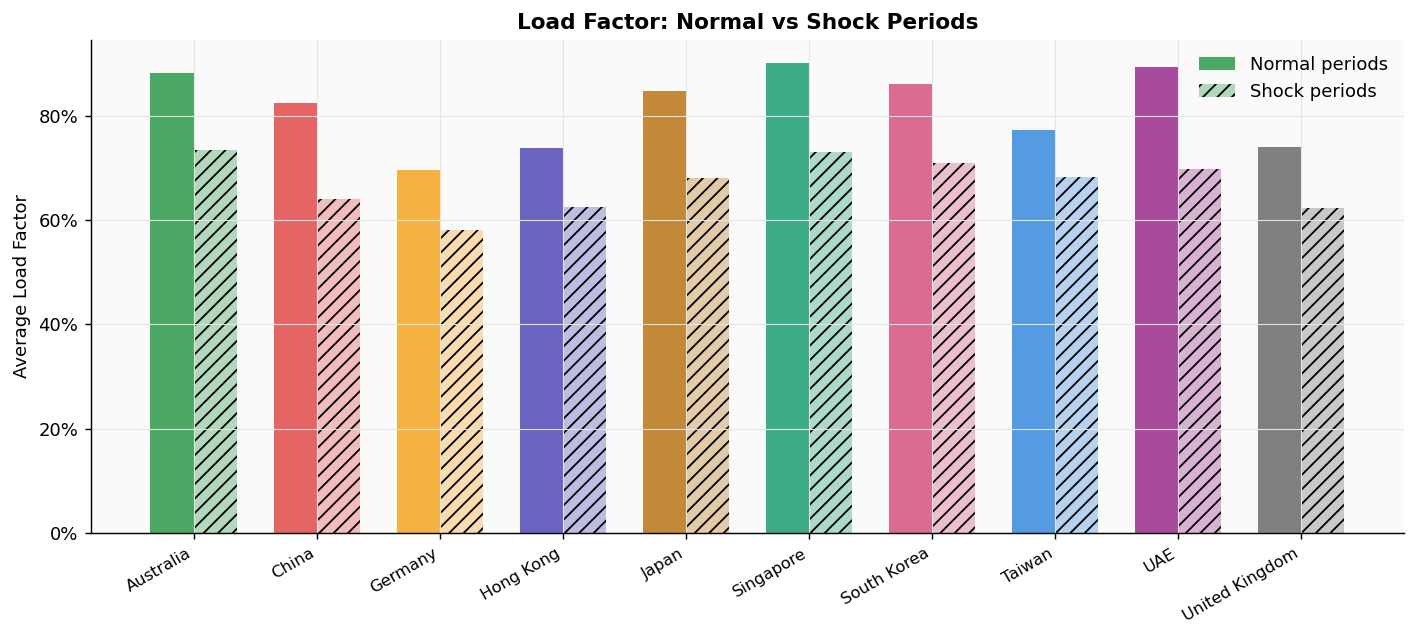

In [23]:
df["is_shocked"] = df["shock_factor"] < 0.95

lf_compare = (
    df.groupby(["market_country_name", "is_shocked"])["load_factor"]
    .mean()
    .unstack()
    .rename(columns={False: "Normal periods", True: "Shock periods"})
    .dropna()
)

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(lf_compare))
width = 0.35
colors_norm  = [MARKET_COLORS.get(
    df[df["market_country_name"] == n]["market_country"].iloc[0], "#999"
) for n in lf_compare.index]

ax.bar(x - width/2, lf_compare["Normal periods"], width, label="Normal periods",
       color=colors_norm, alpha=0.85)
ax.bar(x + width/2, lf_compare["Shock periods"],  width, label="Shock periods",
       color=colors_norm, alpha=0.35, hatch="///")

ax.set_xticks(x)
ax.set_xticklabels(lf_compare.index, rotation=30, ha="right", fontsize=9)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(pct_fmt))
ax.set_ylabel("Average Load Factor")
ax.set_title("Load Factor: Normal vs Shock Periods")
ax.legend()
plt.tight_layout()
plt.show()


---
## 7. Booking Curves & Reading Dates

### 7a. Booking curve shape — Beta distribution by cabin

In [27]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parents[0] / "src"))
from simulator.booking_curves import generate_booking_curves, cumulative_booking_curve

df_curves = generate_booking_curves()
df_cumul  = cumulative_booking_curve(df_curves)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cumulative curves
ax = axes[0]
for cabin, color in CABIN_COLORS.items():
    if cabin in df_cumul.columns:
        ax.plot(df_cumul.index, df_cumul[cabin] * 100, color=color,
                linewidth=2.2, label=cabin.replace("_", " ").title())

ax.axvline(30, color="#999", linestyle="--", alpha=0.5, linewidth=1)
ax.axvline(14, color="#999", linestyle=":",  alpha=0.5, linewidth=1)
ax.text(31, 5, "30d", fontsize=8, color="#999")
ax.text(15, 5, "14d", fontsize=8, color="#999")
ax.set_xlim(90, 1)
ax.set_xlabel("Days Prior to Departure")
ax.set_ylabel("Cumulative % Booked")
ax.set_title("Cumulative Booking Curves by Cabin (90-day window)")
ax.legend()

# Daily arrival distribution
ax2 = axes[1]
for cabin, color in CABIN_COLORS.items():
    if cabin in df_curves.columns:
        ax2.plot(df_curves.index, df_curves[cabin] * 100, color=color,
                 linewidth=1.8, label=cabin.replace("_", " ").title())
ax2.set_xlim(90, 1)
ax2.set_xlabel("Days Prior to Departure")
ax2.set_ylabel("% of Segment Arriving on Day")
ax2.set_title("Daily Booking Arrivals by Cabin")
ax2.legend()

plt.tight_layout()
plt.show()


ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

### 7b. Average % booked at each reading date

In [ ]:
dtp_cols = [c for c in df.columns if c.startswith("dtp") and c.endswith("_pct")]
dtps     = sorted(set(int(c.split("_")[0][3:]) for c in dtp_cols), reverse=True)
cabins   = ["first", "business", "premium_eco", "economy"]

rows = []
for dtp in dtps:
    for cabin in cabins:
        col = f"dtp{dtp:02d}_{cabin}_pct"
        if col in df.columns:
            rows.append({"DTP": dtp, "Cabin": cabin.replace("_"," ").title(),
                         "Pct": df[col].mean()})
dtp_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(11, 5))
for cabin, color in CABIN_COLORS.items():
    sub = dtp_df[dtp_df["Cabin"] == cabin.replace("_"," ").title()]
    ax.plot(sub["DTP"], sub["Pct"] * 100, color=color, linewidth=2.2,
            marker="o", markersize=6, label=cabin.replace("_"," ").title())

ax.set_xlim(max(dtps) + 2, -1)
ax.set_xlabel("Days Prior to Departure (reading date)")
ax.set_ylabel("Avg % of Cabin Booked")
ax.set_title("Average Cumulative % Booked at Each Reading Date")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(pct_fmt))
ax.legend()

for dtp in dtps:
    ax.axvline(dtp, color="#DDD", linewidth=0.8, zorder=0)

plt.tight_layout()
plt.show()


### 7c. Booking pace heatmap — cabin × reading date

In [ ]:
pivot_data = dtp_df.pivot(index="Cabin", columns="DTP", values="Pct") * 100

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(pivot_data.values, cmap="YlOrRd", aspect="auto", vmin=0, vmax=100)

ax.set_xticks(range(len(pivot_data.columns)))
ax.set_xticklabels([f"DTP {d}" for d in pivot_data.columns])
ax.set_yticks(range(len(pivot_data.index)))
ax.set_yticklabels(pivot_data.index)
ax.set_title("% Booked at Each Reading Date — Heatmap by Cabin")

for i in range(len(pivot_data.index)):
    for j in range(len(pivot_data.columns)):
        val = pivot_data.values[i, j]
        ax.text(j, i, f"{val:.1f}%", ha="center", va="center",
                fontsize=9, color="black" if val < 60 else "white")

plt.colorbar(im, ax=ax, label="% Booked", shrink=0.8)
plt.tight_layout()
plt.show()


---
## 8. Correlations & Relationships

### 8a. Correlation heatmap — key numeric columns

In [ ]:
corr_cols = [
    "load_factor", "yield_economy_usd", "yield_overall_blended",
    "revenue_usd", "fuel_price_usd_bbl", "fuel_cost_usd",
    "fuel_pct_revenue", "pax_payload_kg", "rask_usd",
    "seasonal_index", "shock_factor", "distance_km",
]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")

labels = [c.replace("_", "\n") for c in corr_cols]
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, fontsize=8, rotation=45, ha="right")
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=8)
ax.set_title("Pearson Correlation Matrix — Key Simulation Variables")

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        val = corr.values[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7,
                color="white" if abs(val) > 0.5 else "black")

plt.colorbar(im, ax=ax, shrink=0.7, label="Pearson r")
plt.tight_layout()
plt.show()


### 8b. Load factor vs yield — scatter by market

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))

for mkt in markets:
    sub = df[df["market_country"] == mkt].sample(min(200, len(df[df["market_country"]==mkt])),
                                                  random_state=42)
    name = sub["market_country_name"].iloc[0]
    ax.scatter(sub["load_factor"], sub["yield_economy_usd"],
               color=MARKET_COLORS.get(mkt, "#999"), alpha=0.35, s=18, label=name)

# Overall trend
z = np.polyfit(df["load_factor"], df["yield_economy_usd"], 1)
xline = np.linspace(df["load_factor"].min(), df["load_factor"].max(), 100)
ax.plot(xline, np.polyval(z, xline), "k--", linewidth=1.5, label="OLS trend")

ax.xaxis.set_major_formatter(mtick.FuncFormatter(pct_fmt))
ax.yaxis.set_major_formatter(mtick.FuncFormatter(usd_fmt))
ax.set_xlabel("Load Factor")
ax.set_ylabel("Economy Yield (USD)")
ax.set_title("Load Factor vs Economy Yield  (price elasticity signal)")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


### 8c. Fuel price vs revenue — relationship over time

In [ ]:
monthly_agg = df.groupby("date").agg(
    avg_fuel=("fuel_price_usd_bbl", "mean"),
    avg_revenue=("revenue_usd", "mean"),
    avg_lf=("load_factor", "mean")
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Dual axis: fuel price + revenue over time
ax  = axes[0]
ax2 = ax.twinx()
ax.plot(monthly_agg["date"], monthly_agg["avg_fuel"], color="#BA7517",
        linewidth=2, label="Fuel price")
ax2.plot(monthly_agg["date"], monthly_agg["avg_revenue"], color="#185FA5",
         linewidth=2, label="Avg revenue/flight", linestyle="--")
ax.set_ylabel("Fuel (USD/bbl)", color="#BA7517")
ax2.set_ylabel("Avg Revenue (USD)", color="#185FA5")
ax.set_title("Fuel Price vs Revenue Over Time")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)

# Scatter: fuel vs load factor
ax3 = axes[1]
sc = ax3.scatter(monthly_agg["avg_fuel"], monthly_agg["avg_lf"],
                 c=monthly_agg["date"].astype(np.int64),
                 cmap="viridis", s=40, alpha=0.7)
plt.colorbar(sc, ax=ax3, label="Time →")
ax3.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"\${x:.0f}"))
ax3.yaxis.set_major_formatter(mtick.FuncFormatter(pct_fmt))
ax3.set_xlabel("Avg Fuel Price (USD/bbl)")
ax3.set_ylabel("Avg Load Factor")
ax3.set_title("Fuel Price vs Load Factor  (colour = time)")

plt.tight_layout()
plt.show()


### 8d. Seasonal index vs actual load factor — calibration check

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

for mkt in ["JP", "CN", "KR", "AU", "SG"]:
    sub = df[df["market_country"] == mkt]
    name = sub["market_country_name"].iloc[0]
    ax.scatter(sub["seasonal_index"], sub["load_factor"],
               color=MARKET_COLORS.get(mkt, "#999"), alpha=0.25, s=15, label=name)

z = np.polyfit(df["seasonal_index"], df["load_factor"], 1)
xline = np.linspace(df["seasonal_index"].min(), df["seasonal_index"].max(), 100)
ax.plot(xline, np.polyval(z, xline), "k--", linewidth=1.5)

ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:.2f}×"))
ax.yaxis.set_major_formatter(mtick.FuncFormatter(pct_fmt))
ax.set_xlabel("Seasonal Index")
ax.set_ylabel("Actual Load Factor")
ax.set_title("Seasonal Index vs Realised Load Factor (calibration check)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


---
## Summary

| Module | Key output |
|---|---|
| **Demand** | Monthly load factor per route, decomposed into trend × seasonal × shock × noise |
| **Yield** | Cabin-level yield (F/J/W/Y) with price elasticity vs load factor |
| **Fuel** | Ornstein-Uhlenbeck mean-reverting price process, per-flight cost |
| **Payload** | Passenger weight only (seats × 95 kg) — no cargo |
| **Shocks** | Global / country / geopolitical events with exponential decay |
| **Booking curves** | Beta-distribution build-up per cabin; reading date snapshots at DTP 90/60/30/14/7/1 |

**To regenerate data:** `python run.py` (all routes) or `python run.py --routes hnd-lax pvg-lax --countries JP CN`
